# GRB Cosmic Merger Rate Density

Converts BNS and BHNS formation efficiencies into **intrinsic merger rate density R(z) [Gpc⁻³ yr⁻¹]** vs redshift, properly accounting for delay times between stellar birth and compact object merger.

Uses the Neijssel et al. (2019) MSSFR model (Madau & Dickinson 2014 SFR + log-normal metallicity evolution) from the COMPAS `FastCosmicIntegration` post-processing library.

**Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first** to verify the underlying classifications.

## 1. Imports

In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

## 2. Cosmological Grid & MSSFR Model

Neijssel et al. (2019) parameters: `mu0=0.035`, `muz=-0.23`, `sigma0=0.39`.  
`redshift_step=0.01` gives 1001 points — sufficient resolution for rate vs redshift plots.

In [2]:
redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)

sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)
print(f"Redshift grid:  {len(redshifts)} points  (0 → {redshifts.max():.0f})")
print(f"time_first_SF:  {time_first_SF:.1f} Myr")
print(f"times range:    {times.min():.1f} – {times.max():.1f} Myr")
print(f"dPdlogZ shape:  {dPdlogZ.shape}")

Redshift grid:  1001 points  (0 → 10)
time_first_SF:  471.4 Myr
times range:    471.4 – 13786.9 Myr
dPdlogZ shape:  (1001, 1201)


## 3. Memory-Efficient Merger Rate Function

`find_formation_and_merger_rates` in COMPAS allocates an `(n_binaries × n_redshifts)` array which  
crashes the kernel for large populations. This replacement accumulates the sum directly, using only  
O(n_redshifts) memory regardless of population size.

**Bug note:** `t_min` must use `times.min()` (age at z_max ≈ 471 Myr), NOT `times[0]` (age at  
z=0 ≈ 13,787 Myr). The `times` array is monotonically *decreasing* (higher z → earlier universe).

In [3]:
def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Memory-efficient intrinsic merger rate density [Gpc⁻³ yr⁻¹] vs redshift.

    For each binary: formation_rate(z) = SFR(z) × dP/dlogZ(z,Z_i) / p_draw × weight_i / meanMassEvolved
    The merger rate at z_merge is the formation rate at the redshift when the binary was born
    (z_form = redshift at age = t(z_merge) - delay_time).
    """
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)   # handles decreasing times correctly

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)

    # times is DECREASING (times[0]=age_z0≈13787 Myr, times[-1]=age_zmax≈471 Myr)
    # t_min must be the *smallest* time in the grid (times.min()), not times[0]
    t_min = max(time_first_SF, times.min())

    total_merger = np.zeros(n_z)

    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]

        t_form = times - COMPAS_delay_times[i]

        # Only process merger redshifts where formation time is within the grid
        valid = (t_form >= t_min)
        if not valid.any():
            continue

        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]

    return total_merger

## 4. BNS: Load Data & Classify

Gottlieb et al. (2023) hybrid classification: `M_crit = 2.8 M☉`, `q_threshold = 1.2`.

In [4]:
path_BNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'
with h5.File(path_BNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1           = fDCO['M1'][...].squeeze()
    mass2           = fDCO['M2'][...].squeeze()
    weights_BNS     = fDCO['weight'][...].squeeze()
    metallicity_BNS = fDCO['Metallicity1'][...].squeeze()
    mergesHubble    = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BNS          = fDCO['tc'][...].squeeze()
    tform_BNS       = fDCO['tform'][...].squeeze()

mask_BNS = (mergesHubble == 1)
M_tot = mass1[mask_BNS] + mass2[mask_BNS]
q     = np.maximum(mass1[mask_BNS], mass2[mask_BNS]) / np.minimum(mass1[mask_BNS], mass2[mask_BNS])

short_BNS = (M_tot < 2.8) | ((M_tot >= 2.8) & (q < 1.2))
long_BNS  = (M_tot >= 2.8) & (q >= 1.2)

delay_BNS = (tform_BNS + tc_BNS)[mask_BNS]
Z_BNS     = metallicity_BNS[mask_BNS]
w_BNS     = weights_BNS[mask_BNS]

print(f"Merging BNS:  {mask_BNS.sum():,}")
print(f"Short cbGRB:  {short_BNS.sum():,}  ({100*short_BNS.mean():.1f}%)")
print(f"Long  cbGRB:  {long_BNS.sum():,}  ({100*long_BNS.mean():.1f}%)")

Merging BNS:  233,137
Short cbGRB:  189,855  (81.4%)
Long  cbGRB:  43,282  (18.6%)


## 5. BNS Merger Rate Density

`meanMassEvolved = 77,708,655 M☉` — total stellar mass per metallicity simulation (from `GRB_BNS.ipynb`).  
This normalizes the per-binary weights into physical units of Gpc⁻³ yr⁻¹.

In [5]:
meanMassEvolved_BNS = 77708655   # M☉
n_formed_BNS        = sfr / meanMassEvolved_BNS

merger_rates_BNS = {}
for label, mask_grb in [('Short cbGRB', short_BNS),
                         ('Long cbGRB',  long_BNS),
                         ('All BNS',     np.ones(len(delay_BNS), dtype=bool))]:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[mask_grb], delay_BNS[mask_grb], w_BNS[mask_grb],
    )
    merger_rates_BNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc⁻³ yr⁻¹")

Computing Short cbGRB (189,855 systems)...
  z=0: 1131.6  |  z=1: 6,819.6  Gpc⁻³ yr⁻¹
Computing Long cbGRB (43,282 systems)...
  z=0: 74.5  |  z=1: 788.2  Gpc⁻³ yr⁻¹
Computing All BNS (233,137 systems)...
  z=0: 1206.1  |  z=1: 7,607.8  Gpc⁻³ yr⁻¹


### BNS Rate vs Redshift

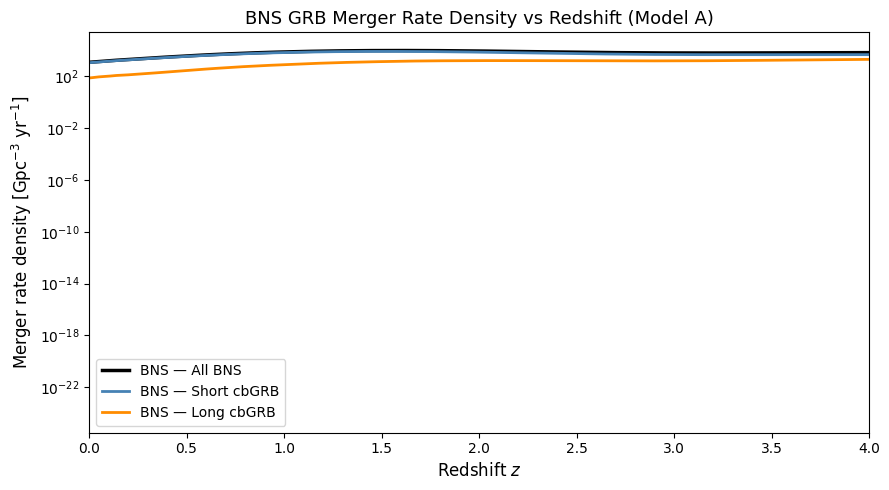

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
styles = {'All BNS': ('black', '-', 2.5), 'Short cbGRB': ('steelblue', '-', 2), 'Long cbGRB': ('darkorange', '-', 2)}
for label, (c, ls, lw) in styles.items():
    ax.plot(redshifts, merger_rates_BNS[label], color=c, ls=ls, lw=lw, label=f'BNS — {label}')
ax.set_xlim(0, 4); ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('BNS GRB Merger Rate Density vs Redshift (Model A)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 6. BHNS: Load Data & Classify (Foucart, a=0.5)

BH spin `a = 0.5` as fiducial. The Foucart (2012) disk mass formula with physical  
disruption pre-check determines whether each BHNS merger produces a GRB.

In [7]:
def r_isco(a_BH):
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    return 3 + Z2 - np.sign(a_BH + 1e-10) * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_NS_km=11.0):
    G = 6.674e-11; c = 3e8; Msun = 1.989e30
    q_r      = M_NS / M_BH
    f_roche  = 0.49 * q_r**(2/3) / (0.6 * q_r**(2/3) + np.log(1 + q_r**(1/3)))
    r_tidal  = (R_NS_km * 1e3) / f_roche
    r_ISCO   = r_isco(a_BH) * G * M_BH * Msun / c**2
    disrupted = r_tidal > r_ISCO
    C_NS  = G * M_NS * Msun / (R_NS_km * 1e3 * c**2)
    eta   = M_NS * M_BH / (M_NS + M_BH)**2
    r_hat = r_isco(a_BH) * M_BH / (M_BH + M_NS)
    M_disk = np.maximum(0.0, 0.406*(1-2*C_NS)/eta**(1/3) - 0.139*r_hat*C_NS + 0.255) * M_NS
    return np.where(disrupted, M_disk, 0.0)

path_BHNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
with h5.File(path_BHNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    M_BH_all     = fDCO['M1'][...].squeeze()
    M_NS_all     = fDCO['M2'][...].squeeze()
    weights_BHNS = fDCO['weight'][...].squeeze()
    Z_BHNS_all   = fDCO['Metallicity1'][...].squeeze()
    merges_BHNS  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BHNS      = fDCO['tc'][...].squeeze()
    tform_BHNS   = fDCO['tform'][...].squeeze()
    stype1       = fDCO['stellarType1'][...].squeeze()

# correct BH/NS assignment
is_BH1   = (stype1 == 14)
M1_orig  = M_BH_all.copy(); M2_orig = M_NS_all.copy()
M_BH_all = np.where(is_BH1, M1_orig, M2_orig)
M_NS_all = np.where(is_BH1, M2_orig, M1_orig)

mask_BHNS = (merges_BHNS == 1)
BH = M_BH_all[mask_BHNS]; NS = M_NS_all[mask_BHNS]
M_disk    = foucart_disk_mass(BH, NS, a_BH=0.5)
long_BHNS = (M_disk >= 0.1)
no_BHNS   = (M_disk == 0.0)

delay_BHNS = (tform_BHNS + tc_BHNS)[mask_BHNS]
Z_BHNS     = Z_BHNS_all[mask_BHNS]
w_BHNS     = weights_BHNS[mask_BHNS]

print(f"Merging BHNS: {mask_BHNS.sum():,}")
print(f"Long cbGRB:   {long_BHNS.sum():,}  ({100*long_BHNS.mean():.1f}%)")
print(f"No GRB:       {no_BHNS.sum():,}  ({100*no_BHNS.mean():.1f}%)")

Merging BHNS: 1,525,553
Long cbGRB:   112,347  (7.4%)
No GRB:       1,413,206  (92.6%)


## 7. BHNS Merger Rate Density

In [8]:
meanMassEvolved_BHNS = 77708655   # M☉ (same simulation setup)
n_formed_BHNS        = sfr / meanMassEvolved_BHNS

merger_rates_BHNS = {}
for label, mask_grb in [('Long cbGRB (a=0.5)', long_BHNS),
                          ('All BHNS',           np.ones(len(delay_BHNS), dtype=bool))]:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[mask_grb], delay_BHNS[mask_grb], w_BHNS[mask_grb],
    )
    merger_rates_BHNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc⁻³ yr⁻¹")

Computing Long cbGRB (a=0.5) (112,347 systems)...
  z=0: 632.2  |  z=1: 3,319.6  Gpc⁻³ yr⁻¹
Computing All BHNS (1,525,553 systems)...
  z=0: 2246.6  |  z=1: 12,204.3  Gpc⁻³ yr⁻¹


## 8. Combined BNS + BHNS Plot

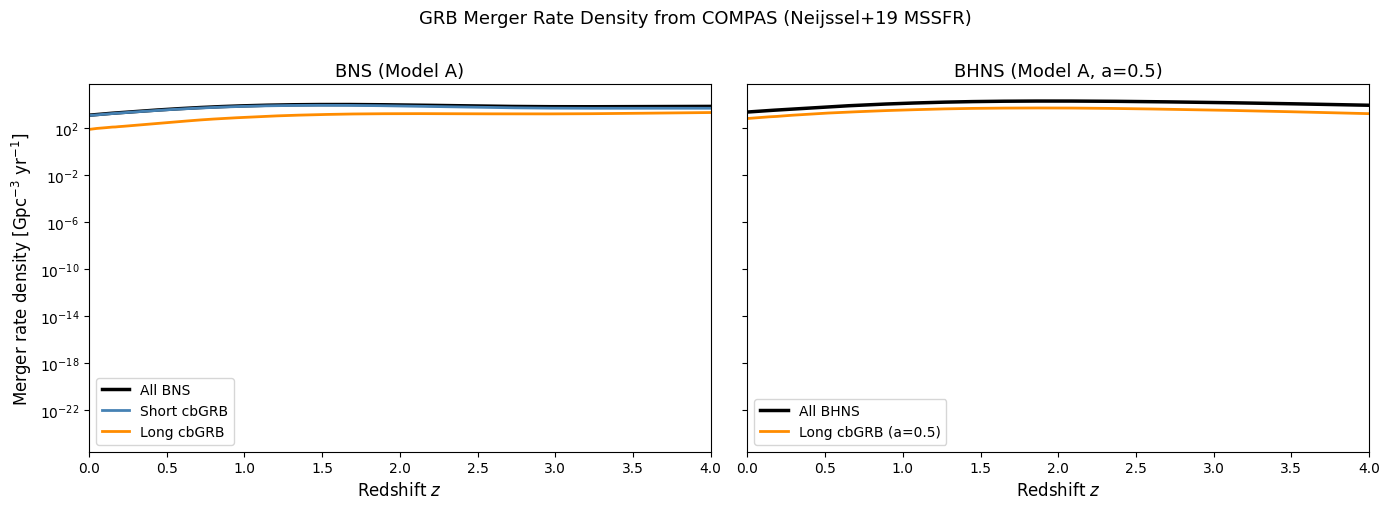

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# BNS
ax = axes[0]
ax.plot(redshifts, merger_rates_BNS['All BNS'],     color='black',      lw=2.5, label='All BNS')
ax.plot(redshifts, merger_rates_BNS['Short cbGRB'], color='steelblue',  lw=2,   label='Short cbGRB')
ax.plot(redshifts, merger_rates_BNS['Long cbGRB'],  color='darkorange', lw=2,   label='Long cbGRB')
ax.set_title('BNS (Model A)', fontsize=13)

# BHNS
ax = axes[1]
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],          color='black',      lw=2.5, label='All BHNS')
ax.plot(redshifts, merger_rates_BHNS['Long cbGRB (a=0.5)'],color='darkorange', lw=2,   label='Long cbGRB (a=0.5)')
ax.set_title('BHNS (Model A, a=0.5)', fontsize=13)

for ax in axes:
    ax.set_xlim(0, 4); ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.legend(fontsize=10)
axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.suptitle('GRB Merger Rate Density from COMPAS (Neijssel+19 MSSFR)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 9. Export

In [10]:
np.save('/Users/josephrodriguez/research visualization/rates_BNS.npy',
        np.array([redshifts,
                  merger_rates_BNS['All BNS'],
                  merger_rates_BNS['Short cbGRB'],
                  merger_rates_BNS['Long cbGRB']]))

np.save('/Users/josephrodriguez/research visualization/rates_BHNS.npy',
        np.array([redshifts,
                  merger_rates_BHNS['All BHNS'],
                  merger_rates_BHNS['Long cbGRB (a=0.5)']]))

print("Rates saved to rates_BNS.npy and rates_BHNS.npy")

Rates saved to rates_BNS.npy and rates_BHNS.npy
